# 🩺 Modelo 2 — Mamografías digitales: SANA vs REQUIERE EVALUACIÓN (RSNA)

**Qué cambia respecto al modelo 1 (CBIS-DDSM):**

| | Modelo 1 | Modelo 2 (este notebook) |
|---|---|---|
| Dataset | CBIS-DDSM (películas escaneadas de los 90) | **RSNA Screening Mammography** (digitales modernas) |
| Pregunta | ¿Benigno o maligno? | **¿Sana o requiere evaluación (cáncer)?** |
| Mamografías sanas | ❌ No | ✅ Sí |
| Preprocesamiento | Imagen completa | **Recorte automático de la mama** (sin bordes, textos ni marcadores) |
| Prueba de estabilidad | — | ✅ Incluida (recortar bordes no debería cambiar el resultado) |

**Antes de empezar (una sola vez):**
1. `Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU T4`.
2. Guarda tu llave de Kaggle en los **Secretos** de Colab (ícono 🔑 de la barra izquierda):
   - **Nombre:** `KAGGLE_API_TOKEN`
   - **Valor:** la llave que copiaste de Kaggle
   - Activa **"Acceso del notebook"**.
3. `Entorno de ejecución → Ejecutar todas`. Cuando pida permiso para **Google Drive**, acéptalo (ahí se guarda el modelo).

⏱️ Tiempo aproximado en T4: **60–90 min** (descarga ~10 min, preprocesamiento ~5–10 min, entrenamiento ~40–60 min).

> ⚠️ Herramienta académica / de apoyo. **No es un diagnóstico médico.**

## 1. Instalación e imports

In [1]:
!pip install -q -U kagglehub

import os, re, io, json, glob, time, zipfile, shutil, warnings
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, average_precision_score
import kagglehub

warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__, "| kagglehub:", kagglehub.__version__)
GPUS = tf.config.list_physical_devices('GPU')
print("GPU:", GPUS if GPUS else "⚠️ NO HAY GPU → Entorno de ejecución > Cambiar tipo > T4 GPU")

TensorFlow: 2.20.0 | kagglehub: 1.0.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuración (lo único que normalmente tocarías)

In [2]:
SEED = 42

# --- Datos ---
DATASET_PNG = 'theoviel/rsna-breast-cancer-512-pngs'   # RSNA convertido a PNG 512x512
COMPETENCIA = 'rsna-breast-cancer-detection'           # de aquí salen las etiquetas (train.csv)
NEGATIVOS_POR_POSITIVO = 6        # sanas por cada imagen con cáncer (todas las de cáncer se usan)
INCLUIR_BIOPSIAS_NEGATIVAS = True # incluir siempre los casos biopsiados que resultaron sin cáncer (casos difíciles)
FRACCION_TEST = 0.15              # por paciente
FRACCION_VAL  = 0.15              # por paciente

# --- Imagen (el MISMO preprocesamiento se usará en la web) ---
BASE = 512                        # toda imagen se lleva a BASE x BASE antes de recortar la mama
IMG_H, IMG_W = 512, 320           # entrada del modelo (las mamografías son altas)

# --- Entrenamiento ---
BATCH_SIZE  = 16
EPOCHS_HEAD = 3                   # fase 1: solo la cabeza
EPOCHS_FINE = 15                  # fase 2: fine-tuning (EarlyStopping corta antes si no mejora)
LR_HEAD     = 1e-3
LR_FINE     = 3e-5
PESOS_BASE  = 'imagenet'
USAR_MIXED_PRECISION = True       # ~2x más rápido en T4

# --- Semáforo (se eligen en VALIDACIÓN) ---
SENSIBILIDAD_OBJETIVO = 0.85      # bajo este umbral = Verde (detecta ~85% de los cánceres)
ESPECIFICIDAD_ROJO    = 0.95      # desde este umbral = Rojo (solo ~5% de las sanas llega a Rojo)

# --- Guardado ---
GUARDAR_EN_DRIVE = True           # el modelo sobrevive si se cae la sesión
RUTA_DATOS_LOCAL = None           # (solo para pruebas fuera de Colab; déjalo en None)
PROBAR_MIS_IMAGENES = False       # True para subir tus propias mamografías en la sección 13

OUT_DIR = '/content/modelo_mamografia_v2'
if GUARDAR_EN_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        OUT_DIR = '/content/drive/MyDrive/modelo_mamografia_v2'
    except ImportError:
        print("No estás en Colab: se guarda en carpeta local.")
os.makedirs(OUT_DIR, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)
if USAR_MIXED_PRECISION and GPUS:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("Política de precisión:", tf.keras.mixed_precision.global_policy().name)
print(f"Entrada: {IMG_H}x{IMG_W} | Salida en: {OUT_DIR}")

Mounted at /content/drive
Política de precisión: mixed_float16
Entrada: 512x320 | Salida en: /content/drive/MyDrive/modelo_mamografia_v2


## 3. Llave de Kaggle (desde los Secretos de Colab)
La llave **no se escribe en el notebook**: se lee del Secreto `KAGGLE_API_TOKEN`, así puedes compartir o descargar este notebook sin exponerla.

In [3]:
def configurar_kaggle():
    token = os.environ.get('KAGGLE_API_TOKEN')
    if not token:
        try:
            from google.colab import userdata
            token = userdata.get('KAGGLE_API_TOKEN')
        except Exception as e:
            raise RuntimeError(
                "No encontré el Secreto 'KAGGLE_API_TOKEN'. Agrégalo en el ícono 🔑 de la barra "
                "izquierda y activa 'Acceso del notebook'. Detalle: " + repr(e))
    if not token or not token.strip():
        raise RuntimeError("El Secreto 'KAGGLE_API_TOKEN' está vacío.")
    os.environ['KAGGLE_API_TOKEN'] = token.strip()
    print("✅ Llave de Kaggle cargada (no se muestra por seguridad).")
    try:
        print("   Conectado como:", kagglehub.whoami())
    except Exception as e:
        print("   ⚠️ No pude verificar la cuenta (puede ser normal):", repr(e)[:120])

if RUTA_DATOS_LOCAL is None:
    configurar_kaggle()

✅ Llave de Kaggle cargada (no se muestra por seguridad).
Kaggle credentials successfully validated.
   Conectado como: {'username': 'diegomesiass'}


## 4. Descarga de las imágenes y las etiquetas

In [4]:
if RUTA_DATOS_LOCAL:
    CARPETA_PNG = RUTA_DATOS_LOCAL
else:
    print("Descargando imágenes (puede tardar ~10 min la primera vez)...")
    CARPETA_PNG = kagglehub.dataset_download(DATASET_PNG)
print("Carpeta de imágenes:", CARPETA_PNG)

PNGS = sorted(glob.glob(os.path.join(CARPETA_PNG, '**', '*.png'), recursive=True))
print(f"PNG encontrados: {len(PNGS):,}")
assert PNGS, "No encontré imágenes PNG en la descarga."
print("Ejemplos:", [os.path.relpath(p, CARPETA_PNG) for p in PNGS[:3]])

# Etiquetas: primero se buscan dentro de la descarga; si no están, se bajan de la competencia
csvs = [c for c in glob.glob(os.path.join(CARPETA_PNG, '**', '*.csv'), recursive=True)
        if os.path.basename(c).lower() == 'train.csv']
if csvs:
    RUTA_CSV = csvs[0]
else:
    RUTA_CSV = kagglehub.competition_download(COMPETENCIA, path='train.csv')
    if os.path.isdir(RUTA_CSV):
        RUTA_CSV = os.path.join(RUTA_CSV, 'train.csv')
print("Etiquetas:", RUTA_CSV)

meta = pd.read_csv(RUTA_CSV)
meta.columns = meta.columns.str.strip().str.lower()
print(f"Filas en train.csv: {len(meta):,} | columnas: {list(meta.columns)}")
print(meta['cancer'].value_counts().rename({0: 'sin cáncer', 1: 'cáncer'}))

Descargando imágenes (puede tardar ~10 min la primera vez)...


100%|██████████| 3.50G/3.50G [00:46<00:00, 80.4MB/s]

Extracting files...


Carpeta de imágenes: /root/.cache/kagglehub/datasets/theoviel/rsna-breast-cancer-512-pngs/versions/2
PNG encontrados: 54,706
Ejemplos: ['10006_1459541791.png', '10006_1864590858.png', '10006_1874946579.png']


100%|██████████| 556k/556k [00:00<00:00, 44.5MB/s]

Extracting zip of train.csv...
Etiquetas: /root/.cache/kagglehub/competitions/rsna-breast-cancer-detection/train.csv
Filas en train.csv: 54,706 | columnas: ['site_id', 'patient_id', 'image_id', 'laterality', 'view', 'age', 'cancer', 'biopsy', 'invasive', 'birads', 'implant', 'density', 'machine_id', 'difficult_negative_case']
cancer
sin cáncer    53548
cáncer         1158
Name: count, dtype: int64


In [5]:
# Vincular cada PNG con su fila de train.csv usando (patient_id, image_id).
# Acepta nombres tipo ".../10006_462822612.png" o ".../10006/462822612.png".
PATRON = re.compile(r'(\d+)[_/](\d+)\.png$', re.IGNORECASE)
filas = []
for p in PNGS:
    m = PATRON.search(p.replace('\\', '/'))
    if m:
        filas.append((int(m.group(1)), int(m.group(2)), p))
archivos = pd.DataFrame(filas, columns=['patient_id', 'image_id', 'ruta'])
print(f"PNG con nombre reconocido: {len(archivos):,} de {len(PNGS):,}")

df = meta.merge(archivos, on=['patient_id', 'image_id'], how='inner')
print(f"Imágenes vinculadas a una etiqueta: {len(df):,}")
assert len(df) > 0, "No pude vincular imágenes con etiquetas: revisa los nombres de archivo de arriba."
if 'biopsy' not in df: df['biopsy'] = 0

# Revisión rápida del formato de las imágenes
muestra = df.sample(min(20, len(df)), random_state=SEED)
tamanos, fondos = [], []
for r in muestra['ruta']:
    with Image.open(r) as im:
        tamanos.append((im.size, im.mode))
        a = np.asarray(im.convert('L'), dtype=np.float32)
        borde = np.concatenate([a[:8].ravel(), a[-8:].ravel(), a[:, :8].ravel(), a[:, -8:].ravel()])
        fondos.append(np.median(borde))
print("Tamaños/modos (muestra):", pd.Series(tamanos).value_counts().to_dict())
print(f"Brillo mediano del borde (fondo): {np.median(fondos):.0f} / 255  (cerca de 0 = fondo negro, correcto)")

PNG con nombre reconocido: 54,706 de 54,706
Imágenes vinculadas a una etiqueta: 54,706
Tamaños/modos (muestra): {((512, 512), 'L'): 20}
Brillo mediano del borde (fondo): 0 / 255  (cerca de 0 = fondo negro, correcto)


## 5. Preprocesamiento (el MISMO se usará en la web)
Pasos: escala de grises → `BASE x BASE` → invertir si el fondo es claro → **mama a la izquierda** → **borrado de lo que no es mama** (etiquetas, marcadores, reglas) → **recorte de la mama** → `IMG_H x IMG_W`.

Está escrito solo con **NumPy + Pillow** (sin TensorFlow) y se guarda como `preprocesamiento_v2.py`, para que la web use exactamente el mismo código.

In [6]:
PREPRO_V2 = r"""
# Preprocesamiento del modelo 2 (idéntico en el notebook y en la web).
# Solo NumPy + Pillow.
import numpy as np
from PIL import Image

BASE, IMG_H, IMG_W = __BASE__, __IMG_H__, __IMG_W__


def a_gris(imagen):
    # Imagen PIL -> arreglo float32 en 0-1 (acepta 8 y 16 bits, color o gris)
    if imagen.mode in ('I;16', 'I;16L', 'I;16B', 'I'):
        a = np.asarray(imagen, dtype=np.float32)
        return np.clip(a / (65535.0 if a.max() > 255 else 255.0), 0, 1)
    return np.asarray(imagen.convert('L'), dtype=np.float32) / 255.0


def redimensionar(a, ancho, alto):
    return np.asarray(Image.fromarray(a.astype(np.float32), mode='F').resize((ancho, alto), Image.BILINEAR))


def tramo_mas_largo(mascara_1d):
    # Inicio y fin (exclusivo) del tramo de True más largo
    mejor, inicio, mejor_ini = 0, None, 0
    for i, v in enumerate(list(mascara_1d) + [False]):
        if v and inicio is None:
            inicio = i
        elif not v and inicio is not None:
            if i - inicio > mejor:
                mejor, mejor_ini = i - inicio, inicio
            inicio = None
    return (mejor_ini, mejor_ini + mejor) if mejor else None


def limpiar_fuera_de_mama(a, umbral=0.10, hueco=12, inicio_max=0.30, largo_min=0.10):
    # La mama (ya a la izquierda) parte cerca del borde del tórax. En cada fila se conserva
    # solo el TRAMO de tejido más largo que empieza cerca de ese borde. Las etiquetas
    # ('RCC'), marcadores, reglas y barras son tramos cortos o separados: se borran.
    # Huecos oscuros de menos de `hueco` píxeles (zonas de grasa) se consideran tejido.
    alto, ancho = a.shape
    limpia = np.zeros_like(a)
    brillante = a > umbral
    for y in range(alto):
        d = np.diff(np.concatenate(([0], brillante[y].astype(np.int8), [0])))
        inicios, fines = list(np.flatnonzero(d == 1)), list(np.flatnonzero(d == -1))
        if not inicios:
            continue
        tramos = [[inicios[0], fines[0]]]
        for i0, f0 in zip(inicios[1:], fines[1:]):
            if i0 - tramos[-1][1] < hueco:
                tramos[-1][1] = f0            # une tramos separados por un hueco pequeño
            else:
                tramos.append([i0, f0])
        validos = [t for t in tramos if t[0] <= inicio_max * ancho and t[1] - t[0] >= largo_min * ancho]
        if validos:
            x0, x1 = max(validos, key=lambda t: t[1] - t[0])
            limpia[y, x0:x1] = a[y, x0:x1]
    return limpia


def caja_mama(a, umbral=0.08, fraccion=0.02, margen=0.02, minimo=0.25):
    # Caja (y0, y1, x0, x1) de la mama: el bloque brillante más grande.
    # Los textos y marcadores quedan fuera porque son tramos cortos.
    alto, ancho = a.shape
    mascara = a > umbral
    cols = tramo_mas_largo(mascara.mean(axis=0) > fraccion)
    if cols is None:
        return 0, alto, 0, ancho
    x0, x1 = cols
    filas = tramo_mas_largo(mascara[:, x0:x1].mean(axis=1) > fraccion)
    if filas is None:
        return 0, alto, 0, ancho
    y0, y1 = filas
    mx, my = int(margen * ancho), int(margen * alto)
    x0, x1 = max(0, x0 - mx), min(ancho, x1 + mx)
    y0, y1 = max(0, y0 - my), min(alto, y1 + my)
    if (x1 - x0) < minimo * ancho or (y1 - y0) < minimo * alto:
        return 0, alto, 0, ancho      # recorte dudoso: se usa la imagen completa
    return y0, y1, x0, x1


def preparar_imagen(imagen):
    # Imagen PIL -> uint8 (IMG_H, IMG_W) lista para el modelo
    a = redimensionar(a_gris(imagen), BASE, BASE)

    borde = np.concatenate([a[:8].ravel(), a[-8:].ravel(), a[:, :8].ravel(), a[:, -8:].ravel()])
    if np.median(borde) > 0.5:          # fondo claro = imagen invertida
        a = 1.0 - a

    mitad = BASE // 2
    if a[:, mitad:].sum() > a[:, :mitad].sum():   # mama siempre a la izquierda
        a = a[:, ::-1]

    limpia = limpiar_fuera_de_mama(a)
    if (limpia > 0.10).mean() < 0.05:   # limpieza dudosa (casi nada quedó): se usa la imagen tal cual
        limpia = a
    y0, y1, x0, x1 = caja_mama(limpia)
    a = redimensionar(np.ascontiguousarray(limpia[y0:y1, x0:x1]), IMG_W, IMG_H)
    return np.clip(np.round(a * 255.0), 0, 255).astype(np.uint8)


def a_entrada(img_u8):
    # uint8 (H, W) -> float32 (1, H, W, 3) en 0-255 (EfficientNet normaliza internamente)
    return np.repeat(img_u8[None, :, :, None].astype(np.float32), 3, axis=-1)
"""
PREPRO_V2 = (PREPRO_V2.replace('__BASE__', str(BASE))
                      .replace('__IMG_H__', str(IMG_H)).replace('__IMG_W__', str(IMG_W)))
with open(os.path.join(OUT_DIR, 'preprocesamiento_v2.py'), 'w', encoding='utf-8') as f:
    f.write(PREPRO_V2)
exec(PREPRO_V2)   # define preparar_imagen(), caja_mama(), a_entrada() en este notebook
print("✅ preprocesamiento_v2.py guardado en", OUT_DIR)

✅ preprocesamiento_v2.py guardado en /content/drive/MyDrive/modelo_mamografia_v2


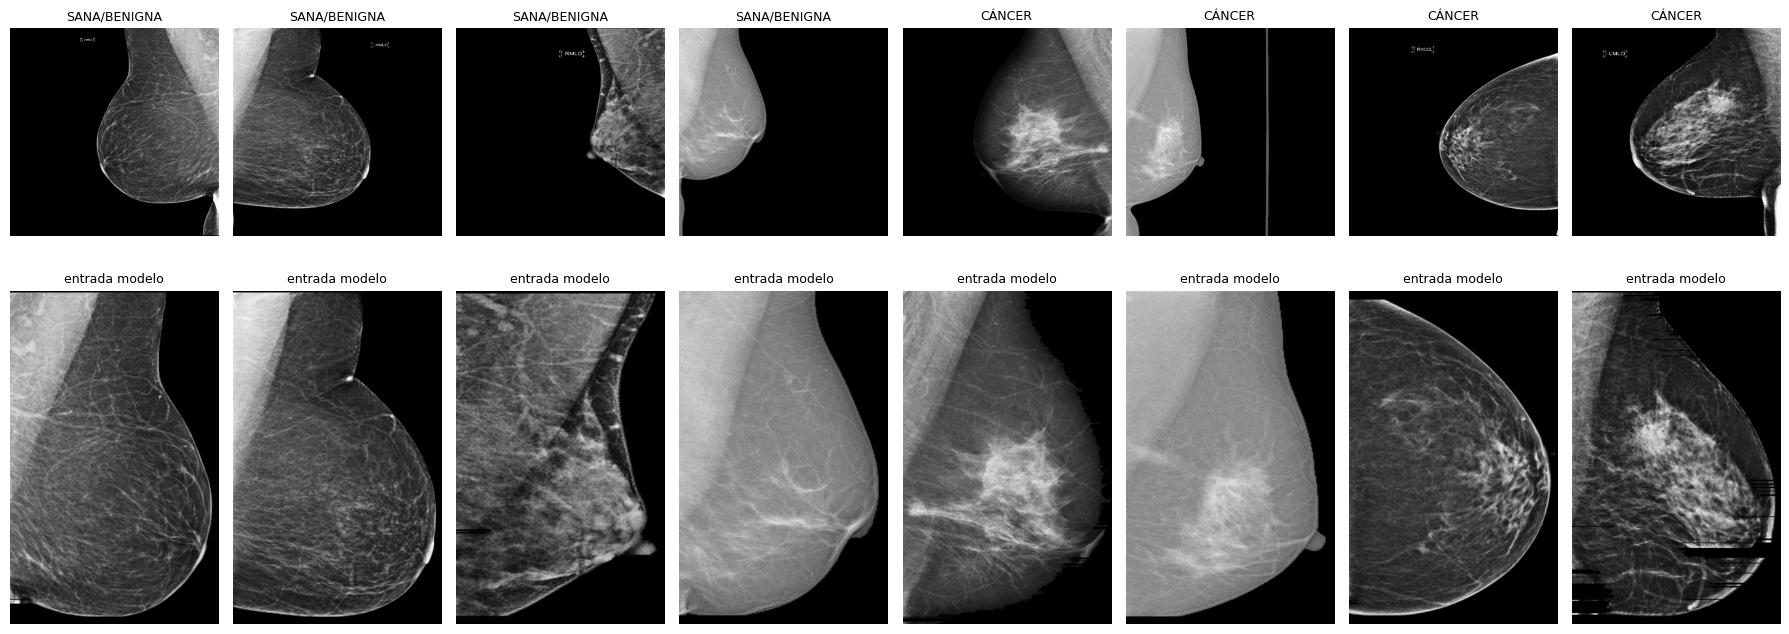

In [7]:
# Vista rápida: arriba la imagen original, abajo lo que recibe el modelo (recortada)
ejemplos = pd.concat([df[df.cancer == 0].sample(4, random_state=SEED),
                      df[df.cancer == 1].sample(4, random_state=SEED)])
fig, ax = plt.subplots(2, 8, figsize=(18, 7))
for i, (_, r) in enumerate(ejemplos.iterrows()):
    with Image.open(r['ruta']) as im:
        ax[0, i].imshow(np.asarray(im.convert('L')), cmap='gray')
        ax[1, i].imshow(preparar_imagen(im), cmap='gray', vmin=0, vmax=255)
    ax[0, i].set_title('CÁNCER' if r.cancer else 'SANA/BENIGNA', fontsize=9)
    ax[1, i].set_title('entrada modelo', fontsize=9)
    ax[0, i].axis('off'); ax[1, i].axis('off')
plt.tight_layout(); plt.show()

## 6. Selección de imágenes y división por paciente
- Se usan **todas** las imágenes con cáncer + `NEGATIVOS_POR_POSITIVO` sanas por cada una (así entra en Colab gratis).
- Los casos **biopsiados sin cáncer** se incluyen siempre (son los más difíciles y los más útiles).
- La división train / validación / test es **por paciente** (sin fuga de datos).

In [8]:
positivos = df[df.cancer == 1]
negativos = df[df.cancer == 0]
neg_biopsia = negativos[negativos.biopsy == 1] if INCLUIR_BIOPSIAS_NEGATIVAS else negativos.iloc[:0]
neg_resto = negativos.drop(neg_biopsia.index)
n_extra = max(0, NEGATIVOS_POR_POSITIVO * len(positivos) - len(neg_biopsia))
n_extra = min(n_extra, len(neg_resto))
seleccion = pd.concat([positivos, neg_biopsia, neg_resto.sample(n_extra, random_state=SEED)])
seleccion = seleccion.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Seleccionadas: {len(seleccion):,} imágenes "
      f"({len(positivos):,} con cáncer, {len(neg_biopsia):,} biopsias negativas, {n_extra:,} sanas)")

# División por paciente, estratificada por "paciente con algún cáncer"
pacientes = seleccion.groupby('patient_id')['cancer'].max()
def dividir(ids, etiquetas, fraccion, semilla):
    n = max(2, round(1 / fraccion))
    sgkf = StratifiedGroupKFold(n_splits=n, shuffle=True, random_state=semilla)
    a, b = next(sgkf.split(ids, etiquetas, groups=ids))
    return ids[a], ids[b]
ids = pacientes.index.values
ids_resto, ids_test = dividir(ids, pacientes.values, FRACCION_TEST, SEED)
ids_train, ids_val = dividir(ids_resto, pacientes.loc[ids_resto].values,
                             FRACCION_VAL / (1 - FRACCION_TEST), SEED + 1)

df_train = seleccion[seleccion.patient_id.isin(ids_train)].reset_index(drop=True)
df_val   = seleccion[seleccion.patient_id.isin(ids_val)].reset_index(drop=True)
df_test  = seleccion[seleccion.patient_id.isin(ids_test)].reset_index(drop=True)

assert not set(df_train.patient_id) & set(df_val.patient_id),  "Fuga train/val"
assert not set(df_train.patient_id) & set(df_test.patient_id), "Fuga train/test"
assert not set(df_val.patient_id)   & set(df_test.patient_id), "Fuga val/test"
for nombre, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    assert d.cancer.nunique() == 2, f"{nombre} no tiene ambas clases"

resumen = pd.DataFrame({n: d['cancer'].value_counts().rename({0: 'SIN CÁNCER', 1: 'CÁNCER'})
                        for n, d in [('train', df_train), ('val', df_val), ('test', df_test)]}).T
resumen['total'] = resumen.sum(axis=1)
resumen['% cáncer'] = (100 * resumen['CÁNCER'] / resumen['total']).round(1)
resumen['pacientes'] = [d.patient_id.nunique() for d in (df_train, df_val, df_test)]
print("✅ Sin fuga de pacientes entre conjuntos\n"); print(resumen)

Seleccionadas: 8,106 imágenes (1,158 con cáncer, 1,811 biopsias negativas, 5,137 sanas)
✅ Sin fuga de pacientes entre conjuntos

cancer  SIN CÁNCER  CÁNCER  total  % cáncer  pacientes
train         4983     818   5801      14.1       3693
val           1005     157   1162      13.5        739
test           960     183   1143      16.0        739


## 7. Preprocesar una sola vez y guardar en memoria
Cada imagen se recorta y achica **una vez** (unos minutos); después el entrenamiento es rápido.

In [9]:
def preprocesar_lote(rutas):
    def una(r):
        with Image.open(r) as im:
            return preparar_imagen(im)
    X = np.zeros((len(rutas), IMG_H, IMG_W), dtype=np.uint8)
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=os.cpu_count() or 2) as ex:
        for i, img in enumerate(ex.map(una, rutas)):
            X[i] = img
            if (i + 1) % 1000 == 0:
                print(f"  {i + 1:,}/{len(rutas):,} ({time.time() - t0:.0f}s)")
    return X

print("Preprocesando train..."); X_train = preprocesar_lote(df_train.ruta.tolist())
print("Preprocesando val...");   X_val   = preprocesar_lote(df_val.ruta.tolist())
print("Preprocesando test...");  X_test  = preprocesar_lote(df_test.ruta.tolist())
y_train, y_val, y_test = (d.cancer.values.astype('float32') for d in (df_train, df_val, df_test))
print(f"✅ Listo: train {X_train.shape}, val {X_val.shape}, test {X_test.shape} "
      f"({(X_train.nbytes + X_val.nbytes + X_test.nbytes) / 1e9:.2f} GB en memoria)")

Preprocesando train...
  1,000/5,801 (38s)
  2,000/5,801 (76s)
  3,000/5,801 (113s)
  4,000/5,801 (150s)
  5,000/5,801 (188s)
Preprocesando val...
  1,000/1,162 (38s)
Preprocesando test...
  1,000/1,143 (38s)
✅ Listo: train (5801, 512, 320), val (1162, 512, 320), test (1143, 512, 320) (1.33 GB en memoria)


## 8. Pipeline de entrenamiento (`tf.data`)

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

def a_entrada_modelo(img):
    # (H, W) uint8 -> (H, W, 3) float32 0-255. EfficientNet normaliza internamente.
    return tf.image.grayscale_to_rgb(tf.cast(img[..., None], tf.float32))

def aumentar(img):
    img = tf.cast(img[..., None], tf.float32)
    escala = tf.random.uniform([], 0.88, 1.0)                  # zoom + traslación leves
    y0 = tf.random.uniform([], 0.0, 1.0 - escala)
    x0 = tf.random.uniform([], 0.0, 1.0 - escala)
    caja = tf.reshape(tf.stack([y0, x0, y0 + escala, x0 + escala]), (1, 4))
    img = tf.image.crop_and_resize(img[None], caja, [0], (IMG_H, IMG_W))[0]
    img = tf.image.random_brightness(img, 20.0)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return tf.image.grayscale_to_rgb(img)

n_tot, n_pos = len(y_train), int(y_train.sum())
PESOS_CLASE = {0: n_tot / (2 * (n_tot - n_pos)), 1: n_tot / (2 * n_pos)}
print("Pesos por clase:", {k: round(v, 3) for k, v in PESOS_CLASE.items()})

def crear_ds(X, y, entrenamiento):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if entrenamiento:
        w = tf.constant([PESOS_CLASE[0], PESOS_CLASE[1]], tf.float32)
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(lambda x, l: (aumentar(x), l, tf.gather(w, tf.cast(l, tf.int32))),
                    num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda x, l: (a_entrada_modelo(x), l), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = crear_ds(X_train, y_train, True)
val_ds   = crear_ds(X_val,   y_val,   False)
test_ds  = crear_ds(X_test,  y_test,  False)

Pesos por clase: {0: 0.582, 1: 3.546}


## 9. Modelo (EfficientNetB0, misma arquitectura que el modelo 1 → compatible con la web y el Grad-CAM)

In [11]:
def construir_modelo(pesos=PESOS_BASE):
    base = tf.keras.applications.EfficientNetB0(include_top=False, weights=pesos,
                                                input_shape=(IMG_H, IMG_W, 3))
    base.trainable = False
    entradas = tf.keras.Input(shape=(IMG_H, IMG_W, 3), name='imagen')
    x = base(entradas, training=False)          # BatchNorm nunca actualiza estadísticas
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.4, name='dropout')(x)
    salida = layers.Dense(1, activation='sigmoid', dtype='float32', name='prob_maligno')(x)
    return tf.keras.Model(entradas, salida, name='clasificador_mamografia_v2'), base

def metricas():
    return [tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
            tf.keras.metrics.Recall(name='sensibilidad'),
            tf.keras.metrics.Precision(name='precision')]

model, base = construir_modelo()
model.compile(optimizer=tf.keras.optimizers.Adam(LR_HEAD), loss='binary_crossentropy', metrics=metricas())
model.summary()
CKPT = os.path.join(OUT_DIR, 'mejor_modelo_v2.keras')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "clasificador_mamografia_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 512, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 16, 10, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob_maligno (Dense)            │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 10. Fase 1 — entrenar solo la cabeza

In [12]:
cb1 = [
    tf.keras.callbacks.ModelCheckpoint(CKPT, monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True),
]
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=cb1)
MEJOR_AUC_F1 = max(h1.history['val_auc'])
print(f"Mejor val AUC fase 1: {MEJOR_AUC_F1:.4f}")

Epoch 1/3
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - auc: 0.4969 - loss: 0.7175 - pr_auc: 0.1440 - precision: 0.1359 - sensibilidad: 0.4632
Epoch 1: val_auc improved from None to 0.51392, saving model to /content/drive/MyDrive/modelo_mamografia_v2/mejor_modelo_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/modelo_mamografia_v2/mejor_modelo_v2.keras
363/363 ━━━━━━━━━━━━━━━━━━━━ 105s 189ms/step - auc: 0.5252 - loss: 0.7125 - pr_auc: 0.1526 - precision: 0.1512 - sensibilidad: 0.5147 - val_auc: 0.5139 - val_loss: 0.7488 - val_pr_auc: 0.1575 - val_precision: 0.1377 - val_sensibilidad: 0.6752
Epoch 2/3
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - auc: 0.5767 - loss: 0.7022 - pr_auc: 0.1834 - precision: 0.1725 - sensibilidad: 0.6293
Epoch 2: val_auc improved from 0.51392 to 0.53786, saving model to /content/drive/MyDrive/modelo_mamografia_v2/mejor_modelo_v2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/modelo_mamografia_v2/mejor_modelo_v2.keras
363/363 ━

## 11. Fase 2 — fine-tuning (bloques 4–7 descongelados, BatchNorm congelado)

In [13]:
base.trainable = True
nombres = [l.name for l in base.layers]
corte = next((i for i, n in enumerate(nombres) if n.startswith('block4a')), len(nombres) - 100)
for i, capa in enumerate(base.layers):
    capa.trainable = (i >= corte) and not isinstance(capa, layers.BatchNormalization)
print(f"Capas entrenables en la base: {sum(c.trainable for c in base.layers)} / {len(base.layers)}")

model.compile(optimizer=tf.keras.optimizers.Adam(LR_FINE), loss='binary_crossentropy', metrics=metricas())
cb2 = [
    tf.keras.callbacks.ModelCheckpoint(CKPT, monitor='val_auc', mode='max', save_best_only=True,
                                       initial_value_threshold=MEJOR_AUC_F1, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=2,
                                         min_lr=1e-7, verbose=1),
]
ep1 = len(h1.history['loss'])
h2 = model.fit(train_ds, validation_data=val_ds, epochs=ep1 + EPOCHS_FINE, initial_epoch=ep1, callbacks=cb2)

Capas entrenables en la base: 128 / 238
Epoch 4/18
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - auc: 0.5958 - loss: 0.6870 - pr_auc: 0.1878 - precision: 0.1812 - sensibilidad: 0.6045
Epoch 4: val_auc did not improve from 0.56018
363/363 ━━━━━━━━━━━━━━━━━━━━ 148s 231ms/step - auc: 0.6067 - loss: 0.6763 - pr_auc: 0.1890 - precision: 0.1847 - sensibilidad: 0.5966 - val_auc: 0.5559 - val_loss: 0.7319 - val_pr_auc: 0.1755 - val_precision: 0.1598 - val_sensibilidad: 0.7134 - learning_rate: 3.0000e-05
Epoch 5/18
362/363 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - auc: 0.6346 - loss: 0.6575 - pr_auc: 0.2228 - precision: 0.1895 - sensibilidad: 0.6157
Epoch 5: val_auc improved from 0.56018 to 0.57429, saving model to /content/drive/MyDrive/modelo_mamografia_v2/mejor_modelo_v2.keras

Epoch 5: finished saving model to /content/drive/MyDrive/modelo_mamografia_v2/mejor_modelo_v2.keras
363/363 ━━━━━━━━━━━━━━━━━━━━ 30s 82ms/step - auc: 0.6415 - loss: 0.6575 - pr_auc: 0.2273 - precision: 0.1967 - sensibilidad:

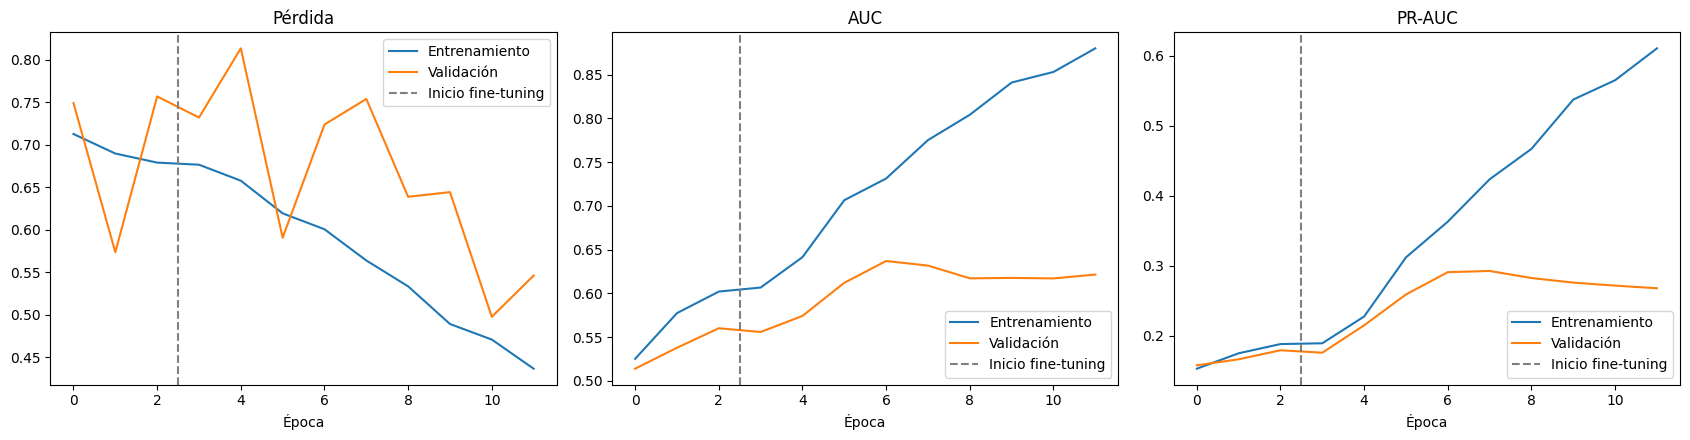

✅ Cargado el mejor modelo: /content/drive/MyDrive/modelo_mamografia_v2/mejor_modelo_v2.keras


In [14]:
hist = {k: h1.history[k] + h2.history.get(k, []) for k in h1.history}
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for a, m, t in zip(ax, ['loss', 'auc', 'pr_auc'], ['Pérdida', 'AUC', 'PR-AUC']):
    a.plot(hist[m], label='Entrenamiento'); a.plot(hist['val_' + m], label='Validación')
    a.axvline(ep1 - 0.5, color='gray', ls='--', label='Inicio fine-tuning')
    a.set_title(t); a.set_xlabel('Época'); a.legend()
plt.tight_layout(); plt.show()

model = tf.keras.models.load_model(CKPT)   # el mejor según val AUC
print("✅ Cargado el mejor modelo:", CKPT)

## 12. Umbrales del semáforo (en validación) y evaluación final en TEST
- **Verde** bajo `UMBRAL` (elegido para detectar ≥85% de los cánceres de validación).
- **Rojo** desde `UMBRAL_ROJO` (elegido para que solo ~5% de las sanas llegue a Rojo).
- **Amarillo** entre ambos.
El test solo se usa aquí.

In [15]:
p_val  = model.predict(val_ds,  verbose=0).ravel().astype('float64')
p_test = model.predict(test_ds, verbose=0).ravel().astype('float64')

fpr_v, tpr_v, thr_v = roc_curve(y_val, p_val)
thr_v = np.clip(thr_v, 0, 1)
UMBRAL = float(thr_v[np.argmax(tpr_v >= SENSIBILIDAD_OBJETIVO)])
ok = np.where(fpr_v <= 1 - ESPECIFICIDAD_ROJO)[0]
UMBRAL_ROJO = float(thr_v[ok[-1]]) if len(ok) else 0.9
UMBRAL_ROJO = max(UMBRAL_ROJO, UMBRAL + 1e-6)
print(f"UMBRAL (Verde→Amarillo): {UMBRAL:.4f} | UMBRAL_ROJO (Amarillo→Rojo): {UMBRAL_ROJO:.4f}")

def nivel(p):
    return 'Verde' if p < UMBRAL else ('Amarillo' if p < UMBRAL_ROJO else 'Rojo')

def auc_ic(y, p, n=1000):
    rng, vals = np.random.default_rng(SEED), []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) == 2:
            vals.append(roc_auc_score(y[i], p[i]))
    return np.percentile(vals, [2.5, 97.5])

def reporte(y, p, nombre):
    auc = roc_auc_score(y, p); lo, hi = auc_ic(y, p)
    tn, fp, fn, tp = confusion_matrix(y, (p >= UMBRAL).astype(int), labels=[0, 1]).ravel()
    r = {'AUC': auc, 'AUC_IC95': [float(lo), float(hi)], 'PR_AUC': average_precision_score(y, p),
         'sensibilidad': tp / (tp + fn), 'especificidad': tn / (tn + fp),
         'VPP': tp / (tp + fp) if tp + fp else 0.0, 'VPN': tn / (tn + fn) if tn + fn else 0.0,
         'n': int(len(y)), 'prevalencia': float(np.mean(y))}
    print(f"\n=== {nombre} (umbral {UMBRAL:.3f}) ===")
    print(f"AUC: {auc:.4f}  (IC95%: {lo:.3f}–{hi:.3f}) | PR-AUC: {r['PR_AUC']:.3f} (azar = {r['prevalencia']:.3f})")
    for k in ['sensibilidad', 'especificidad', 'VPP', 'VPN']:
        print(f"{k:>14}: {r[k]:.3f}")
    niveles = pd.crosstab(pd.Series(y).map({0: 'SIN CÁNCER', 1: 'CÁNCER'}).rename('real'),
                          pd.Series([nivel(v) for v in p]).rename('semáforo'))
    print("\nSemáforo por clase real:\n", niveles.reindex(columns=['Verde', 'Amarillo', 'Rojo'], fill_value=0))
    return r, np.array([[tn, fp], [fn, tp]])

r_val, _        = reporte(y_val,  p_val,  'VALIDACIÓN')
r_test, cm_test = reporte(y_test, p_test, 'TEST (resultado final)')

for col in ['site_id', 'density']:
    if col in df_test:
        print(f"\nAUC en test por {col}:")
        for v, g in df_test.assign(p=p_test).groupby(col):
            if g.cancer.nunique() == 2:
                print(f"  {str(v):<6} n={len(g):5d}  AUC={roc_auc_score(g.cancer, g.p):.3f}")

UMBRAL (Verde→Amarillo): 0.3938 | UMBRAL_ROJO (Amarillo→Rojo): 0.7921

=== VALIDACIÓN (umbral 0.394) ===
AUC: 0.6373  (IC95%: 0.589–0.687) | PR-AUC: 0.292 (azar = 0.135)
  sensibilidad: 0.854
 especificidad: 0.270
           VPP: 0.154
           VPN: 0.922

Semáforo por clase real:
 semáforo    Verde  Amarillo  Rojo
real                             
CÁNCER         23       104    30
SIN CÁNCER    271       690    44

=== TEST (resultado final) (umbral 0.394) ===
AUC: 0.6577  (IC95%: 0.617–0.699) | PR-AUC: 0.289 (azar = 0.160)
  sensibilidad: 0.880
 especificidad: 0.274
           VPP: 0.188
           VPN: 0.923

Semáforo por clase real:
 semáforo    Verde  Amarillo  Rojo
real                             
CÁNCER         22       139    22
SIN CÁNCER    263       656    41

AUC en test por site_id:
  1      n=  715  AUC=0.697
  2      n=  428  AUC=0.615

AUC en test por density:
  A      n=   61  AUC=0.627
  B      n=  292  AUC=0.693
  C      n=  328  AUC=0.690


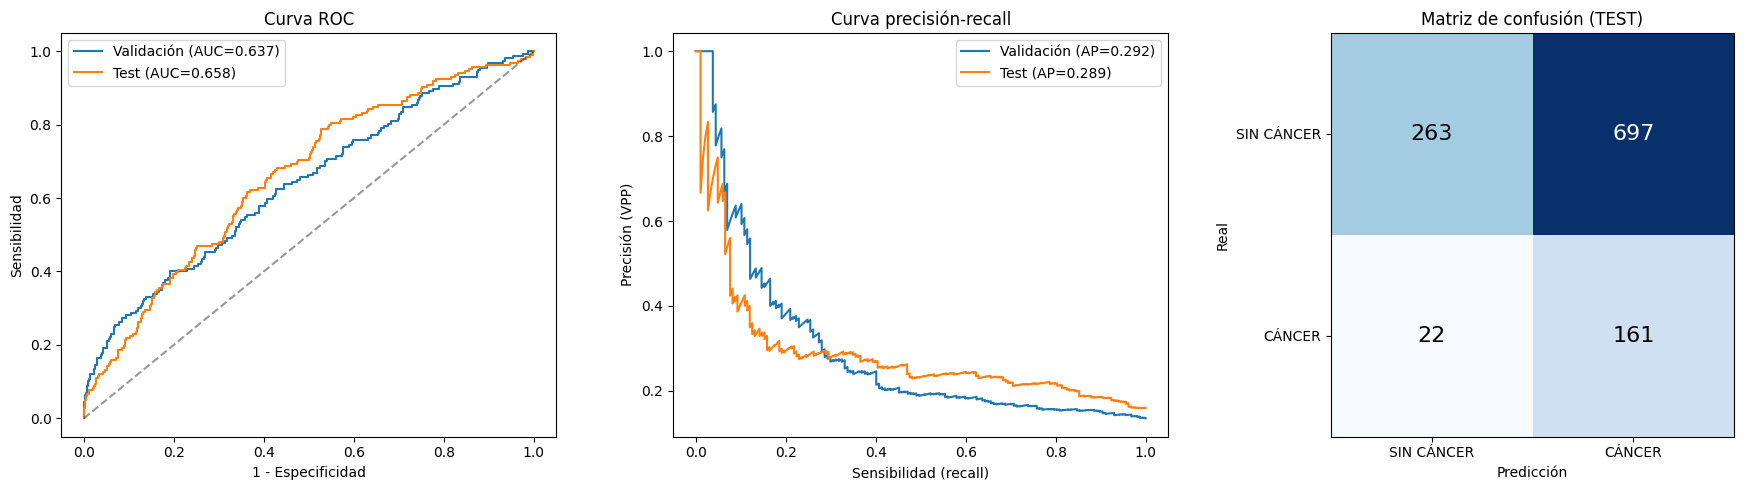

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for y, p, n in [(y_val, p_val, 'Validación'), (y_test, p_test, 'Test')]:
    f, t, _ = roc_curve(y, p); ax[0].plot(f, t, label=f"{n} (AUC={roc_auc_score(y, p):.3f})")
ax[0].plot([0, 1], [0, 1], 'k--', alpha=.4)
ax[0].set_xlabel('1 - Especificidad'); ax[0].set_ylabel('Sensibilidad'); ax[0].set_title('Curva ROC'); ax[0].legend()

for y, p, n in [(y_val, p_val, 'Validación'), (y_test, p_test, 'Test')]:
    from sklearn.metrics import precision_recall_curve
    pr, rc, _ = precision_recall_curve(y, p); ax[1].plot(rc, pr, label=f"{n} (AP={average_precision_score(y, p):.3f})")
ax[1].set_xlabel('Sensibilidad (recall)'); ax[1].set_ylabel('Precisión (VPP)'); ax[1].set_title('Curva precisión-recall'); ax[1].legend()

ax[2].imshow(cm_test, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax[2].text(j, i, cm_test[i, j], ha='center', va='center', fontsize=16,
                   color='white' if cm_test[i, j] > cm_test.max() / 2 else 'black')
ax[2].set_xticks([0, 1], ['SIN CÁNCER', 'CÁNCER']); ax[2].set_yticks([0, 1], ['SIN CÁNCER', 'CÁNCER'])
ax[2].set_xlabel('Predicción'); ax[2].set_ylabel('Real'); ax[2].set_title('Matriz de confusión (TEST)')
plt.tight_layout(); plt.show()

## 13. Prueba de estabilidad, Grad-CAM y tus propias imágenes
**Estabilidad:** al modelo 1, recortar solo 2% de los bordes le cambiaba el nivel en 1 de cada 4 imágenes. Con el recorte de la mama esto debería bajar mucho.

In [17]:
def predecir_imagen(imagen):
    x = a_entrada(preparar_imagen(imagen))
    return float(model(x, training=False)[0, 0])

muestra_est = df_test.sample(min(200, len(df_test)), random_state=SEED)
difs, cambios = [], 0
for r in muestra_est['ruta']:
    with Image.open(r) as im:
        im = im.convert('L'); w, h = im.size
        p1 = predecir_imagen(im)
        p2 = predecir_imagen(im.crop((int(w * .02), int(h * .02), int(w * .98), int(h * .98))))
    difs.append(abs(p1 - p2) * 100); cambios += nivel(p1) != nivel(p2)
print(f"Recortar 2% de los bordes ({len(difs)} imágenes de test):")
print(f"  cambio medio {np.mean(difs):.1f} pts | máximo {np.max(difs):.1f} pts | "
      f"cambian de nivel {cambios} de {len(difs)} ({100 * cambios / len(difs):.0f}%)")
print("  (modelo 1: medio 8.1 pts, máximo 31.8 pts, 25% cambiaba de nivel)")

Recortar 2% de los bordes (200 imágenes de test):
  cambio medio 4.9 pts | máximo 21.2 pts | cambian de nivel 24 de 200 (12%)
  (modelo 1: medio 8.1 pts, máximo 31.8 pts, 25% cambiaba de nivel)


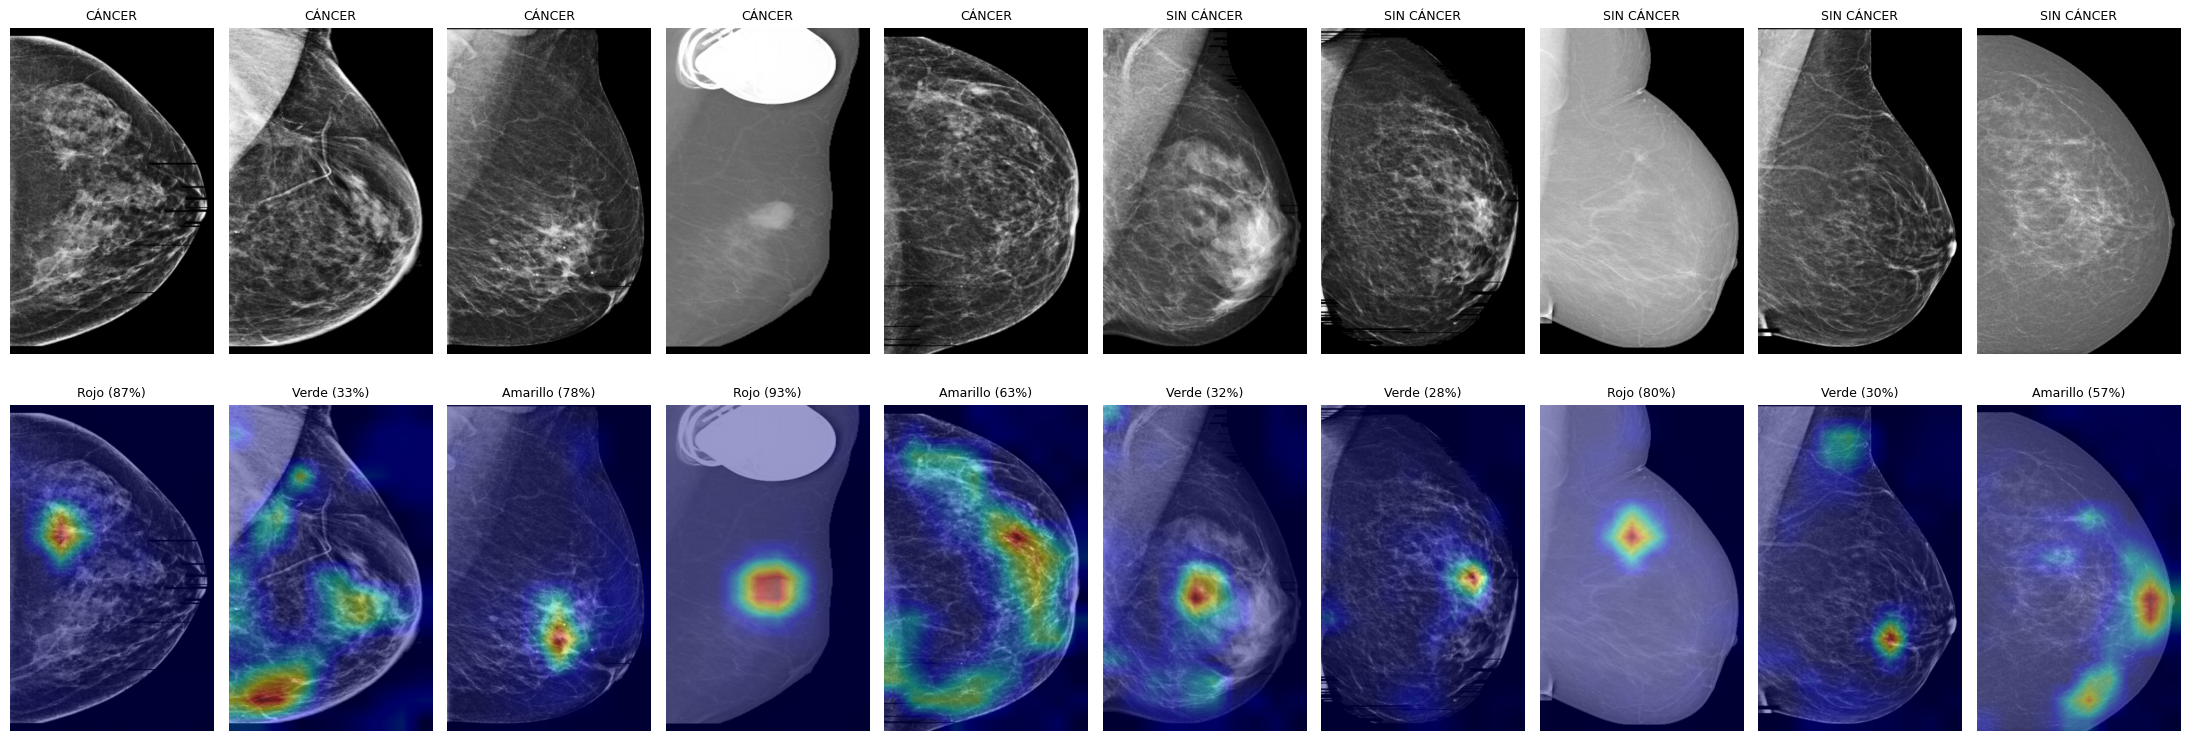

In [18]:
# Grad-CAM: con GAP + una neurona, el peso de cada canal es el peso de la capa final (igual que en la web)
base_m = next(l for l in model.layers if isinstance(l, tf.keras.Model))
pesos_cabeza = model.get_layer('prob_maligno').get_weights()[0][:, 0]

def mapa_calor(img_u8):
    act = base_m(a_entrada(img_u8), training=False)[0].numpy().astype('float32')
    calor = np.maximum((act * pesos_cabeza).sum(-1), 0)
    calor = calor / (calor.max() + 1e-8)
    return np.asarray(Image.fromarray(calor, mode='F').resize((IMG_W, IMG_H), Image.BILINEAR))

ejemplos = pd.concat([df_test[df_test.cancer == 1].sample(min(5, int(df_test.cancer.sum())), random_state=1),
                      df_test[df_test.cancer == 0].sample(5, random_state=1)])
fig, ax = plt.subplots(2, len(ejemplos), figsize=(2.2 * len(ejemplos), 8))
for i, (_, r) in enumerate(ejemplos.iterrows()):
    with Image.open(r['ruta']) as im:
        img = preparar_imagen(im)
    p = float(model(a_entrada(img), training=False)[0, 0])
    ax[0, i].imshow(img, cmap='gray'); ax[0, i].set_title('CÁNCER' if r.cancer else 'SIN CÁNCER', fontsize=9)
    ax[1, i].imshow(img, cmap='gray'); ax[1, i].imshow(mapa_calor(img), cmap='jet', alpha=0.4)
    ax[1, i].set_title(f"{nivel(p)} ({p:.0%})", fontsize=9)
    ax[0, i].axis('off'); ax[1, i].axis('off')
plt.tight_layout(); plt.show()

In [19]:
# Tus propias mamografías (jpg/png): pon PROBAR_MIS_IMAGENES = True en la configuración
if PROBAR_MIS_IMAGENES:
    try:
        from google.colab import files
        for nombre, contenido in files.upload().items():
            with Image.open(io.BytesIO(contenido)) as im:
                p = predecir_imagen(im)
            print(f"{nombre} → {nivel(p)} (índice {p:.0%})")
    except ImportError:
        print("Esta celda solo funciona en Google Colab.")

## 14. Exportar para la web (modelo float32 + config + preprocesamiento)

In [20]:
tf.keras.mixed_precision.set_global_policy('float32')
# OJO: se construye con pesos='imagenet' a propósito. EfficientNet agrega una capa de escala
# ('rescaling_1') SOLO cuando weights='imagenet'; con weights=None esa capa no existe y el
# modelo exportado procesaría distinto que el entrenado (error que tenía el notebook 1).
# Los pesos de ImageNet se reemplazan enseguida por los entrenados.
modelo_web, _ = construir_modelo(pesos=PESOS_BASE)
modelo_web.set_weights(model.get_weights())
RUTA_WEB = os.path.join(OUT_DIR, 'modelo_mamografia_v2.keras')
modelo_web.save(RUTA_WEB)

x_prueba = a_entrada(X_test[0])
dif = abs(float(modelo_web(x_prueba)[0, 0]) - float(model(x_prueba)[0, 0]))
print(f"Diferencia float32 vs original: {dif:.5f}")
assert dif < 0.01, "El modelo exportado no coincide con el entrenado: NO lo uses y avísame."


def a_float(v):
    return v if isinstance(v, (list, int)) else float(v)

config = {
    'version': 'v2', 'dataset': f'RSNA Screening Mammography ({DATASET_PNG})',
    'pregunta': 'probabilidad de CÁNCER (sigmoid) - sana/benigna vs requiere evaluación',
    'base': BASE, 'img_h': IMG_H, 'img_w': IMG_W,
    'umbral': UMBRAL, 'umbral_rojo': UMBRAL_ROJO,
    'sensibilidad_objetivo': SENSIBILIDAD_OBJETIVO, 'especificidad_rojo': ESPECIFICIDAD_ROJO,
    'backbone': 'EfficientNetB0',
    'entrada': 'ver preprocesamiento_v2.py: gris -> BASExBASE -> invertir si fondo claro -> mama a la '
               'izquierda -> recorte de la mama -> IMG_HxIMG_W -> uint8 -> 3 canales float32 0-255',
    'metricas_test': {k: a_float(v) for k, v in r_test.items()},
    'metricas_val':  {k: a_float(v) for k, v in r_val.items()},
    'estabilidad_recorte_2pct': {'cambio_medio_pts': float(np.mean(difs)),
                                 'cambian_de_nivel_pct': float(100 * cambios / len(difs))},
    'n_imagenes': {'train': int(len(y_train)), 'val': int(len(y_val)), 'test': int(len(y_test))},
    'tensorflow': tf.__version__,
}
with open(os.path.join(OUT_DIR, 'config.json'), 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

ZIP = os.path.join('/content' if os.path.isdir('/content') else OUT_DIR, 'modelo_mamografia_v2_web.zip')
with zipfile.ZipFile(ZIP, 'w', zipfile.ZIP_DEFLATED) as z:
    for n in ['modelo_mamografia_v2.keras', 'config.json', 'preprocesamiento_v2.py']:
        z.write(os.path.join(OUT_DIR, n), n)
print("📦 Paquete listo:", ZIP, f"({os.path.getsize(ZIP) / 1e6:.1f} MB)")
print(json.dumps(config['metricas_test'], indent=2))
try:
    from google.colab import files
    files.download(ZIP)
except ImportError:
    pass

Diferencia float32 vs original: 0.00127
📦 Paquete listo: /content/modelo_mamografia_v2_web.zip (15.1 MB)
{
  "AUC": 0.6577242714025501,
  "AUC_IC95": [
    0.6170055422949032,
    0.6988814672670665
  ],
  "PR_AUC": 0.28886807806161763,
  "sensibilidad": 0.8797814207650273,
  "especificidad": 0.27395833333333336,
  "VPP": 0.18764568764568765,
  "VPN": 0.9228070175438596,
  "n": 1143,
  "prevalencia": 0.16010499000549316
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ✅ Listo
Se descargó `modelo_mamografia_v2_web.zip` (también queda en tu Google Drive, carpeta `modelo_mamografia_v2`) con:
- `modelo_mamografia_v2.keras` — el modelo (float32, apto para CPU).
- `config.json` — tamaño de entrada, **umbrales del semáforo** y métricas.
- `preprocesamiento_v2.py` — el preprocesamiento idéntico al del entrenamiento (NumPy + Pillow).

**Para integrarlo en la página:** descarga también este notebook con sus resultados (`Archivo → Descargar → .ipynb`) y pon ambos archivos en la carpeta `modelo_cnn_v2` del proyecto.

**Cómo leer los resultados:** las métricas clave son el **AUC en TEST** (con su intervalo), la **sensibilidad** y la **especificidad**. Como la mayoría de las imágenes son sanas, mira también la **PR-AUC** comparada con el azar. Y compara la **prueba de estabilidad** con la del modelo 1.

**Limitaciones:** RSNA proviene de pocos centros y equipos; el modelo puede rendir distinto con otros equipos. Las etiquetas son por **mama** (no por lesión), por lo que una vista puede estar etiquetada como cáncer aunque la lesión se vea poco en ella.